## 10. Cox Process — Doubly Stochastic Poisson

A **Cox process** (or doubly stochastic Poisson process) generalizes the Poisson process by letting the intensity $\lambda(t)$ itself be a random process. Formally:

1. First, a non-negative random measure $\Lambda(t)$ or random field $\lambda(x)$ is realized.
2. Conditional on this realization, events occur as an inhomogeneous Poisson process with that intensity.

If we write $N(A)$ for the number of points in a set $A$, then:
$$\mathbb{E}[N(A) \mid \lambda(\cdot)] = \int_A \lambda(z)\,dz, \qquad \text{Var}[N(A) \mid \lambda(\cdot)] = \int_A \lambda(z)\,dz$$

But unconditionally, the variance exceeds the mean:
$$\text{Var}[N(A)] = \mathbb{E}[\Lambda(A)] + \text{Var}[\Lambda(A)] > \mathbb{E}[N(A)]$$

This **overdispersion** is the hallmark of a Cox process and distinguishes it from a pure Poisson process.

Important subclasses:
- **Mixed Poisson process**: $\lambda(t) \equiv \Lambda$ is a random variable (constant in time/space).
- **Markov-modulated Poisson process (MMPP)**: $\lambda(t)$ switches between discrete values according to a continuous-time Markov chain.
- **Log-Gaussian Cox process (LGCP)**: $\lambda(x) = \exp\{Z(x)\}$ where $Z$ is a Gaussian random field.
- 

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import nbinom

np.random.seed(42)


## 11. Mixed Poisson Process — Random Constant Intensity

The simplest Cox process is a **mixed Poisson process**, where the intensity is a random variable $\Lambda$ but constant over time. Conditional on $\Lambda = \lambda$:
$$N(T) \sim \text{Poisson}(\lambda T)$$

If $\Lambda \sim \text{Gamma}(\alpha, \beta)$ (shape-rate parameterization), then unconditionally:
$$N(T) \sim \text{Negative-Binomial}\left(r = \alpha,\; p = \frac{\beta}{\beta + T}\right)$$

The Negative Binomial distribution has variance greater than its mean, demonstrating overdispersion.


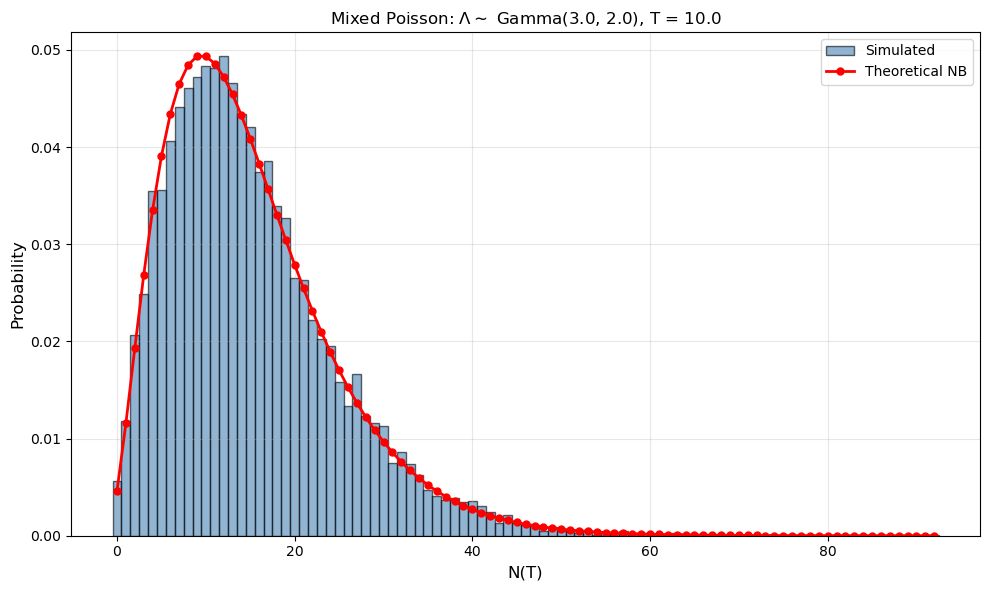

Empirical mean:    15.150
Empirical variance: 90.908
Theoretical mean:   15.000
Theoretical var:    90.000
Index of dispersion: 6.001 (Poisson would be 1.0)


In [11]:
np.random.seed(42)

T = 10.0
alpha = 3.0
beta = 2.0
n_sims = 10000

counts = []
for _ in range(n_sims):
    lam = np.random.gamma(alpha, 1.0 / beta)
    N = np.random.poisson(lam * T)
    counts.append(N)

counts = np.array(counts)
mean_count = np.mean(counts)
var_count = np.var(counts)

# Theoretical NB parameters
r_nb = alpha
p_nb = beta / (beta + T)
n_vals = np.arange(0, np.max(counts) + 1)
theoretical_pmf = nbinom.pmf(n_vals, r_nb, p_nb)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(counts, bins=np.arange(-0.5, np.max(counts) + 1.5), density=True,
        alpha=0.6, color='steelblue', edgecolor='black', label='Simulated')
ax.plot(n_vals, theoretical_pmf, 'ro-', label='Theoretical NB', linewidth=2, markersize=5)

ax.set_xlabel('N(T)', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title(rf'Mixed Poisson: $\Lambda \sim$ Gamma({alpha}, {beta}), T = {T}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(rf"Empirical mean:    {mean_count:.3f}")
print(rf"Empirical variance: {var_count:.3f}")
print(rf"Theoretical mean:   {r_nb * (1 - p_nb) / p_nb:.3f}")
print(rf"Theoretical var:    {r_nb * (1 - p_nb) / p_nb**2:.3f}")
print(rf"Index of dispersion: {var_count / mean_count:.3f} (Poisson would be 1.0)")


## 12. Markov-Modulated Poisson Process (MMPP)

An MMPP is a Cox process where the intensity $\lambda(t)$ switches between a finite set of values according to a continuous-time Markov chain (CTMC). It is widely used in telecommunications and queueing to model "bursty" traffic.

Consider a 2-state CTMC with generator:
$$Q = \begin{pmatrix} -q_{01} & q_{01} \\ q_{10} & -q_{10} \end{pmatrix}$$

When the chain is in state $i$, arrivals occur as a Poisson process with rate $\lambda_i$. The intensity path is a step function that jumps between $\lambda_0$ and $\lambda_1$.

The simulation is exact:
1. Simulate the CTMC path (exponential sojourn times in each state).
2. In each constant-intensity interval $[t_k, t_{k+1})$, generate Poisson($\lambda_i \Delta t$) arrivals uniformly.
3. 

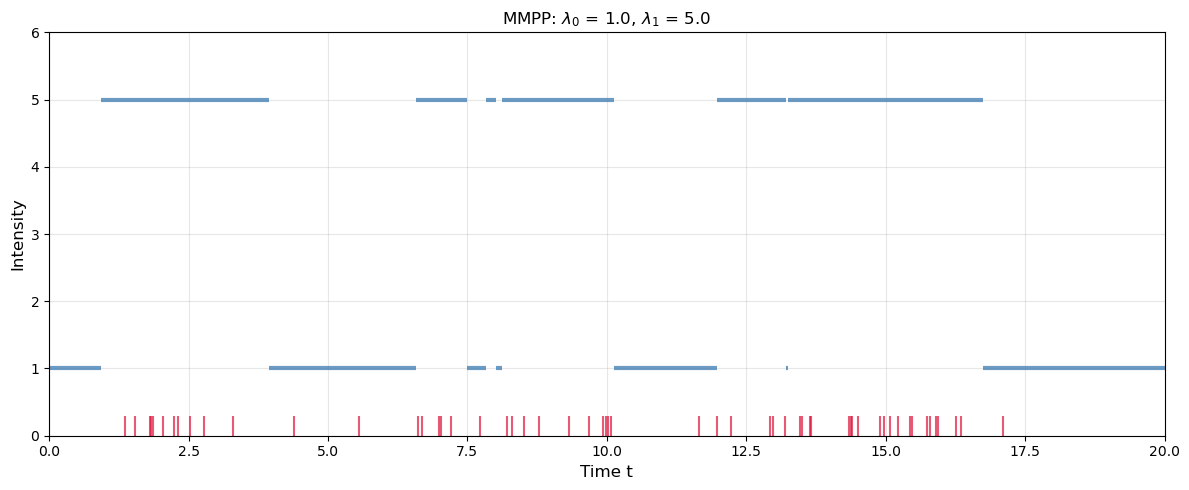

Total arrivals in [0, 20.0]: 56


In [12]:
np.random.seed(42)

T = 20.0
lambda_states = np.array([1.0, 5.0])
Q = np.array([[-0.5, 0.5],
              [1.0, -1.0]])

# Simulate CTMC path
t = 0.0
state = 0
times = [0.0]
states_path = [0]

while t < T:
    rate_leave = -Q[state, state]
    dt = np.random.exponential(1.0 / rate_leave)
    t += dt
    if t > T:
        times.append(T)
        states_path.append(state)
        break
    times.append(t)
    state = 1 - state
    states_path.append(state)

# Simulate arrivals in each constant-intensity interval
arrivals = []
for i in range(len(times) - 1):
    t0, t1 = times[i], times[i + 1]
    lam = lambda_states[states_path[i]]
    dt = t1 - t0
    n = np.random.poisson(lam * dt)
    arr = np.random.uniform(t0, t1, n)
    arrivals.extend(arr)

arrivals = np.sort(np.array(arrivals))

# Plotting
fig, ax = plt.subplots(figsize=(12, 5))

for i in range(len(times) - 1):
    t0, t1 = times[i], times[i + 1]
    lam = lambda_states[states_path[i]]
    ax.hlines(lam, t0, t1, colors='steelblue', linewidth=3, alpha=0.8)

for arr in arrivals:
    ax.vlines(arr, 0, 0.3, colors='crimson', linewidth=1.5, alpha=0.7)

ax.set_xlim(0, T)
ax.set_ylim(0, max(lambda_states) + 1)
ax.set_xlabel('Time t', fontsize=12)
ax.set_ylabel('Intensity', fontsize=12)
ax.set_title(rf'MMPP: $\lambda_0$ = {lambda_states[0]}, $\lambda_1$ = {lambda_states[1]}')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(rf"Total arrivals in [0, {T}]: {len(arrivals)}")


## 13. Log-Gaussian Cox Process in 2D

A **log-Gaussian Cox process (LGCP)** is a spatial Cox process where the intensity field is:
$$\lambda(x, y) = \exp\{m + s \cdot Z(x, y)\}$$

and $Z(x, y)$ is a Gaussian random field with mean zero and some covariance kernel (e.g., squared exponential). The exponential ensures positivity.

LGCPs are the workhorse of modern spatial point-process statistics because they naturally produce **clustering**: regions where $Z$ is high attract many points, and regions where $Z$ is low are sparse. This is fundamentally different from a homogeneous Poisson process, which exhibits complete spatial randomness.

We simulate $Z$ by smoothing white noise with a Gaussian kernel (a fast spectral approximation), then thin from a homogeneous Poisson process.


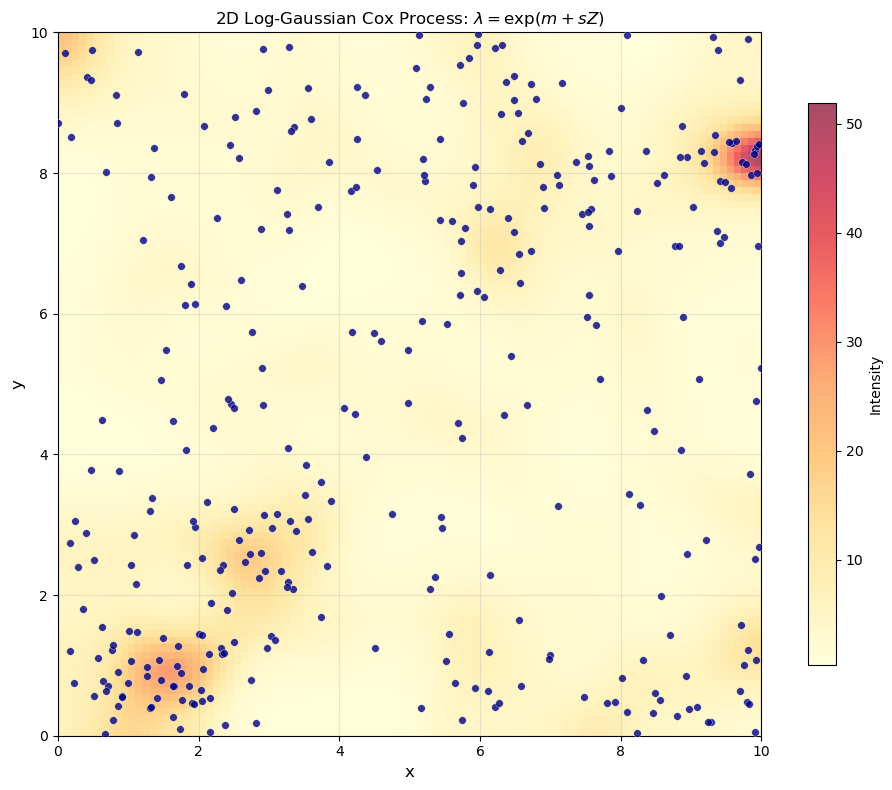

Mean intensity: 3.833
Max intensity:  51.922
Simulated points: 343
Expected (homogeneous): 383.3


In [13]:
np.random.seed(42)

from scipy import ndimage

W, H = 10, 10
grid_res = 100

# White noise field
white = np.random.randn(grid_res, grid_res)

# Convolve with Gaussian kernel to obtain a smooth Gaussian-like field
sigma_grid = 5.0
Z = ndimage.gaussian_filter(white, sigma=sigma_grid)

# Standardize
Z = (Z - np.mean(Z)) / np.std(Z)

# Log-Gaussian intensity
m = 1.0
s = 0.8
Lambda = np.exp(m + s * Z)

# Simulation by thinning
area = W * H
lam_max = np.max(Lambda)

N_hom = np.random.poisson(lam_max * area)
x_hom = np.random.uniform(0, W, N_hom)
y_hom = np.random.uniform(0, H, N_hom)

ix = np.clip((x_hom / W * grid_res).astype(int), 0, grid_res - 1)
iy = np.clip((y_hom / H * grid_res).astype(int), 0, grid_res - 1)

u = np.random.uniform(0, 1, N_hom)
keep = u <= Lambda[iy, ix] / lam_max
x_cox = x_hom[keep]
y_cox = y_hom[keep]

fig, ax = plt.subplots(figsize=(10, 8))

extent = [0, W, 0, H]
im = ax.imshow(Lambda, extent=extent, origin='lower', cmap='YlOrRd', alpha=0.7)
plt.colorbar(im, ax=ax, label='Intensity', shrink=0.8)

ax.scatter(x_cox, y_cox, c='navy', s=30, alpha=0.8,
           edgecolors='white', linewidth=0.3, zorder=3)

ax.set_xlim(0, W)
ax.set_ylim(0, H)
ax.set_aspect('equal')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title(rf'2D Log-Gaussian Cox Process: $\lambda = \exp(m + sZ)$')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(rf"Mean intensity: {np.mean(Lambda):.3f}")
print(rf"Max intensity:  {lam_max:.3f}")
print(rf"Simulated points: {len(x_cox)}")
print(rf"Expected (homogeneous): {np.mean(Lambda) * area:.1f}")


## 14. Overdispersion: Poisson vs Cox

The defining diagnostic of a Cox process is **overdispersion**: the variance of the count in any region exceeds the mean. For a pure Poisson process:
$$\text{Var}[N(A)] = \mathbb{E}[N(A)]$$

For a Cox process:
$$\text{Var}[N(A)] = \mathbb{E}[N(A)] + \text{Var}\left[\int_A \lambda(z)\,dz\right] > \mathbb{E}[N(A)]$$

The ratio $\text{Var}/\text{Mean}$ is called the **index of dispersion**. It equals 1 for Poisson and is greater than 1 for any non-degenerate Cox process.


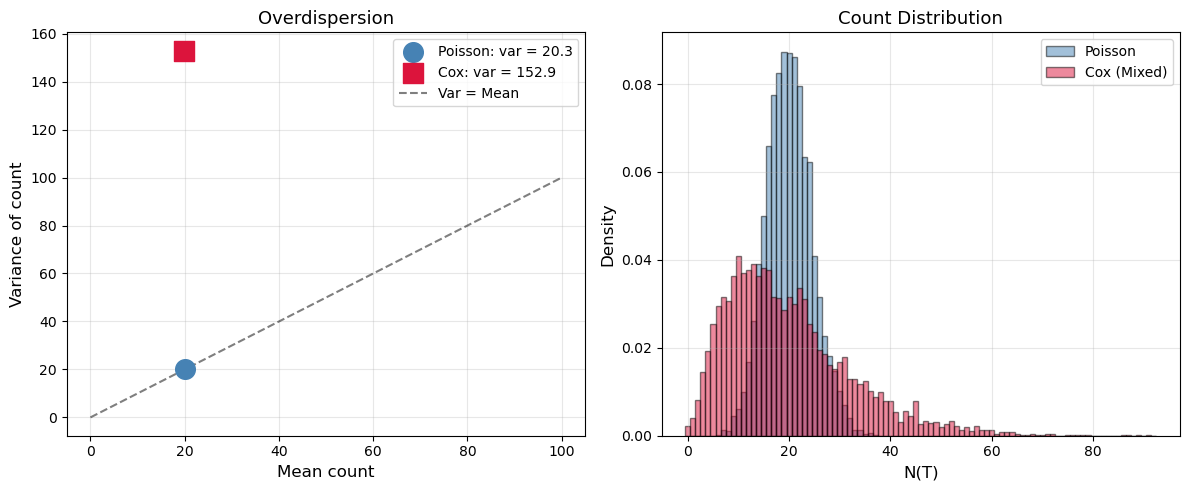

Poisson: mean = 20.014, var = 20.332
Cox:     mean = 19.912, var = 152.910
Cox index of dispersion: 7.679


In [14]:
np.random.seed(42)

T = 10.0
n_realizations = 5000

# Homogeneous Poisson
lam_fixed = 2.0
counts_poisson = np.random.poisson(lam_fixed * T, n_realizations)

# Cox: Mixed Poisson with Gamma Lambda
alpha, beta = 3.0, 1.5
counts_cox = np.empty(n_realizations)
for i in range(n_realizations):
    lam = np.random.gamma(alpha, 1.0 / beta)
    counts_cox[i] = np.random.poisson(lam * T)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
ax1.scatter(np.mean(counts_poisson), np.var(counts_poisson), s=200,
            c='steelblue', marker='o', zorder=3,
            label=rf'Poisson: var = {np.var(counts_poisson):.1f}')
ax1.scatter(np.mean(counts_cox), np.var(counts_cox), s=200,
            c='crimson', marker='s', zorder=3,
            label=rf'Cox: var = {np.var(counts_cox):.1f}')
ax1.plot([0, 100], [0, 100], 'k--', alpha=0.5, label='Var = Mean')
ax1.set_xlabel('Mean count', fontsize=12)
ax1.set_ylabel('Variance of count', fontsize=12)
ax1.set_title('Overdispersion', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
bins = np.arange(-0.5, max(np.max(counts_poisson), np.max(counts_cox)) + 2)
ax2.hist(counts_poisson, bins=bins, density=True, alpha=0.5,
         color='steelblue', edgecolor='black', label='Poisson')
ax2.hist(counts_cox, bins=bins, density=True, alpha=0.5,
         color='crimson', edgecolor='black', label='Cox (Mixed)')
ax2.set_xlabel('N(T)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Count Distribution', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(rf"Poisson: mean = {np.mean(counts_poisson):.3f}, var = {np.var(counts_poisson):.3f}")
print(rf"Cox:     mean = {np.mean(counts_cox):.3f}, var = {np.var(counts_cox):.3f}")
print(rf"Cox index of dispersion: {np.var(counts_cox) / np.mean(counts_cox):.3f}")


## 15. Summary

| Process | Intensity $\lambda$ | Key Property | Unconditional Count |
|---------|---------------------|--------------|---------------------|
| **Poisson** | Deterministic, constant | Var = Mean | Poisson |
| **Mixed Poisson** | Random constant $\Lambda$ | Overdispersed | Negative Binomial (if $\Lambda \sim$ Gamma) |
| **MMPP** | CTMC-driven step function | Bursty arrivals | Complex, overdispersed |
| **LGCP** | Log-Gaussian random field | Spatial clustering | Overdispersed, analytically intractable |

**Key insight:** The Cox process bridges Poisson random measures and random fields. By randomizing the intensity, we gain flexibility to model clustering, bursts, and heterogeneity that a pure Poisson process cannot capture.
